# **Exploratory Data Analysis**
The purpose of the exploratory data analysis is to understand the structure, distribution, and quality of the dataset and evaluate its suitability for embedding-based semantic search.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
# Set stylistic parameters for beautifully formatted graphs
sns.set_theme(style="whitegrid", palette="pastel")
plt.rcParams["figure.figsize"] = (12, 6)

In [ ]:
df = pd.read_csv("/content/cleaned_flipkart_data (2).csv")
df.head()

,uniq_id,image,product_name,description,brand,retail_price,discounted_price,category,product_text
0,c2d766ca982eca8304150849735ffef9,"[""http://img5a.flixcart.com/image/short/u/4/a/...",alisha solid women s cycling shorts,key features of alisha solid women s cycling s...,alisha,999.0,379.0,clothing women s clothing lingerie sleep swimw...,alisha solid women s cycling shorts key featur...
1,7f7036a6d550aaa89d34c77bd39a5e48,"[""http://img6a.flixcart.com/image/sofa-bed/j/f...",fabhomedecor fabric double sofa bed,fabhomedecor fabric double sofa bed finish col...,fabhomedecor,32157.0,22646.0,furniture living room furniture sofa beds futo...,fabhomedecor fabric double sofa bed fabhomedec...
2,f449ec65dcbc041b6ae5e6a32717d01b,"[""http://img5a.flixcart.com/image/shoe/7/z/z/r...",aw bellies,key features of aw bellies sandals wedges heel...,aw,999.0,499.0,footwear women s footwear ballerinas aw bellies,aw bellies key features of aw bellies sandals ...
3,0973b37acd0c664e3de26e97e5571454,"[""http://img5a.flixcart.com/image/short/6/2/h/...",alisha solid women s cycling shorts,key features of alisha solid women s cycling s...,alisha,699.0,267.0,clothing women s clothing lingerie sleep swimw...,alisha solid women s cycling shorts key featur...
4,bc940ea42ee6bef5ac7cea3fb5cfbee7,"[""http://img5a.flixcart.com/image/pet-shampoo/...",sicons all purpose arnica dog shampoo,specifications of sicons all purpose arnica do...,sicons,220.0,210.0,pet supplies grooming skin coat care shampoo s...,sicons all purpose arnica dog shampoo specific...


In [ ]:
from google.colab import drive
drive.mount('/content/drive')
import os

os.listdir('/content/drive/MyDrive/')

Mounted at /content/drive


['UIUX REPORT.gdoc', 'Econometric Note.gdoc', 'Colab Notebooks']

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### 1. Category Distribution

/tmp/ipykernel_833/2516964065.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_categories.values, y=top_categories.index, palette="viridis")


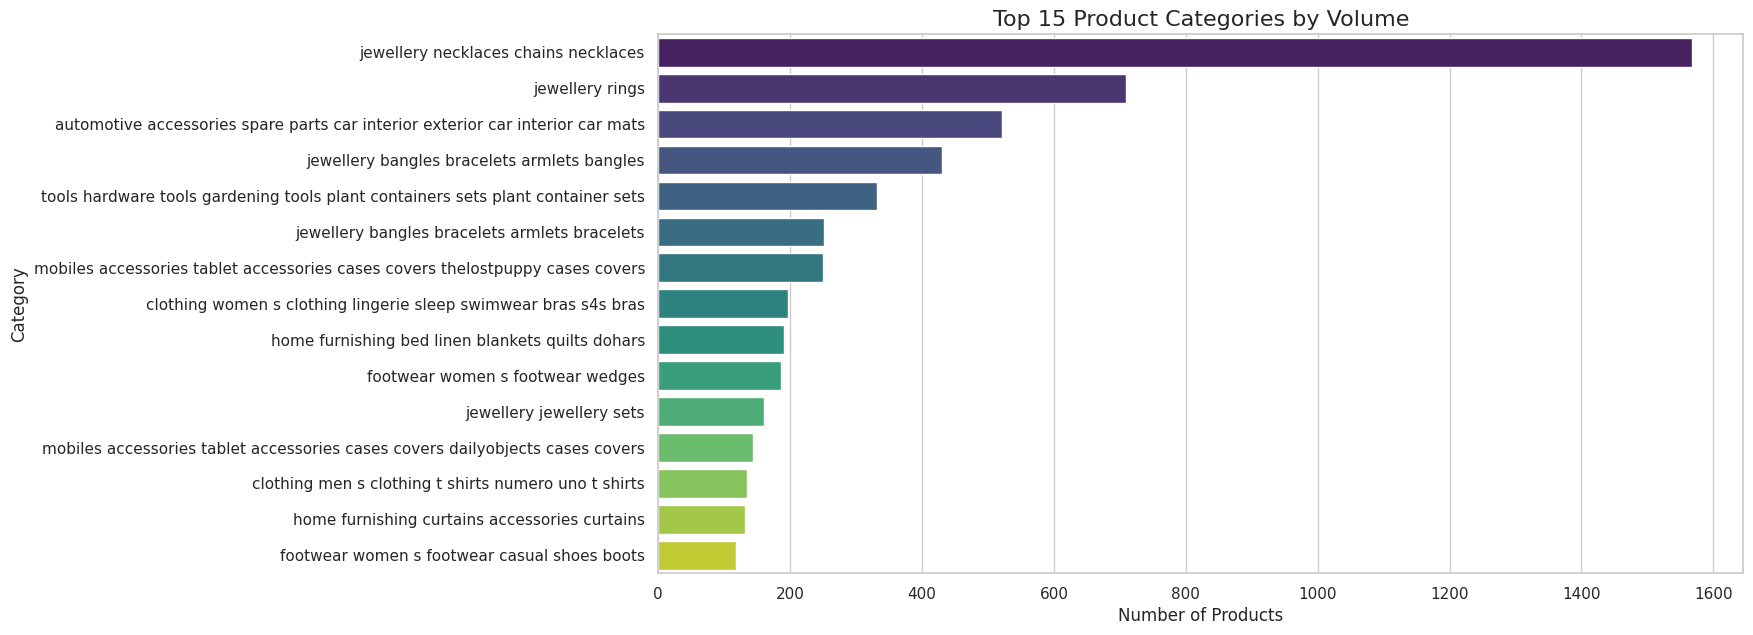

In [ ]:
top_categories = df['category'].value_counts().head(15)

plt.figure(figsize=(14, 7))
sns.barplot(x=top_categories.values, y=top_categories.index, palette="viridis")
plt.title('Top 15 Product Categories by Volume', fontsize=16)
plt.xlabel('Number of Products')
plt.ylabel('Category')
plt.show()

The product distribution across categories is imbalanced, with a few categories dominating the dataset. This may lead to biased search results toward frequently occurring categories. Such imbalance can affect model generalization across different product types.

### 2. Price and Target Discounts

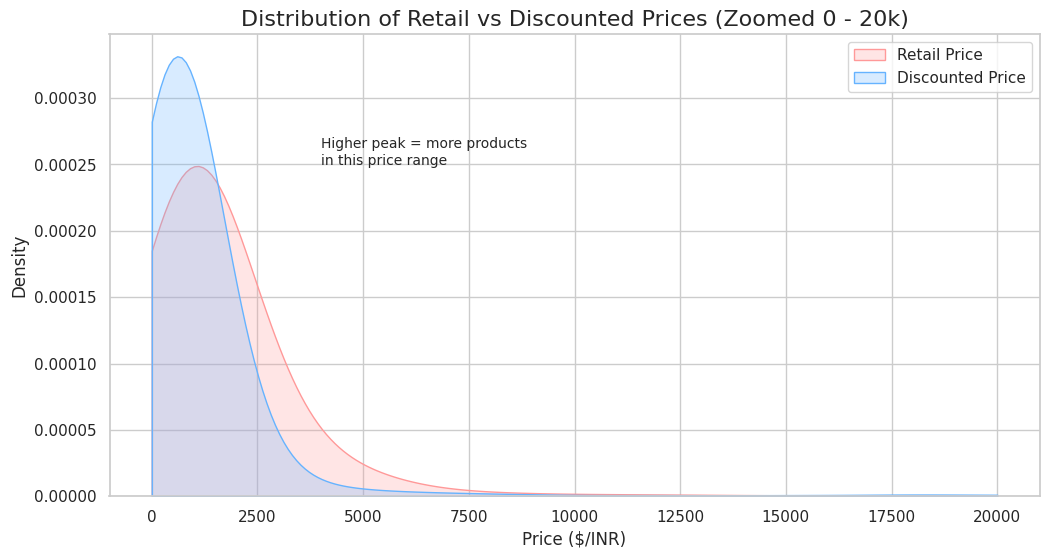

In [ ]:
plt.figure(figsize=(12, 6))

# KDE plots
sns.kdeplot(df['retail_price'], label='Retail Price', fill=True, color="#ff9999", clip=(0, 20000))
sns.kdeplot(df['discounted_price'], label='Discounted Price', fill=True, color="#66b3ff", clip=(0, 20000))

# Titles and labels
plt.title('Distribution of Retail vs Discounted Prices (Zoomed 0 - 20k)', fontsize=16)
plt.xlabel('Price ($/INR)')
plt.ylabel('Density')

# 🔥 Annotation (adjust position if needed)
plt.text(4000, 0.00025, 'Higher peak = more products\nin this price range', fontsize=10)

plt.legend()
plt.show()

Retail and discounted prices are right-skewed, with most products in the lower price range. Discounted prices follow a similar pattern but are slightly lower. This shows that discounting does not significantly change the overall price distribution.

### 3. Top Brands Market Share

/tmp/ipykernel_833/2891794393.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_brands.index, y=top_brands.values, palette="rocket")


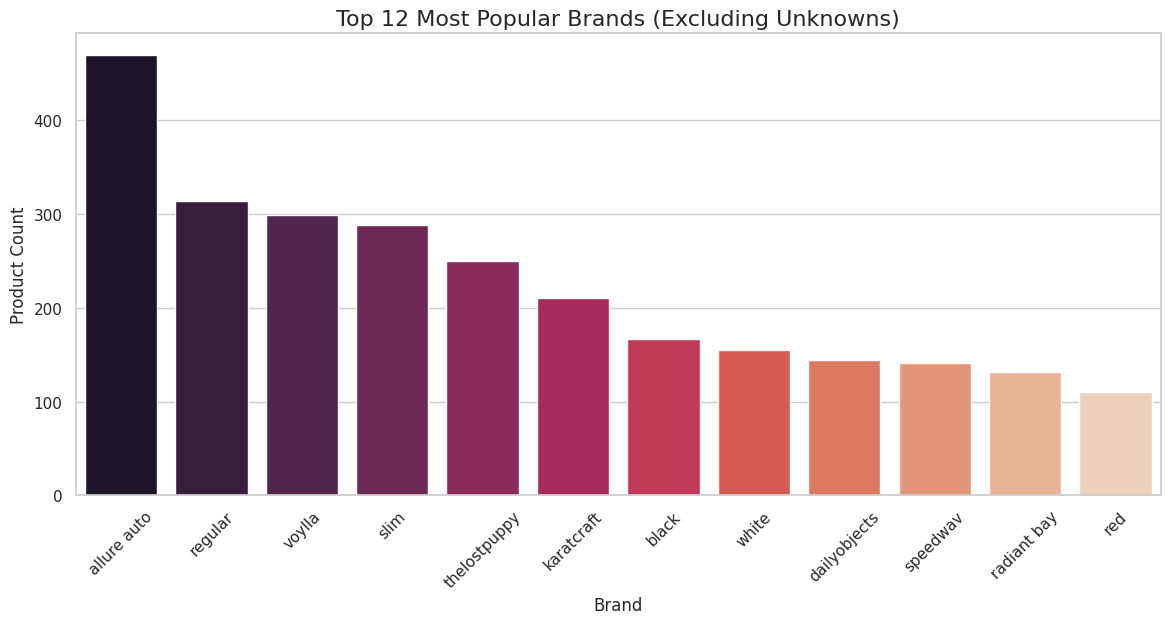

In [ ]:
top_brands = df[df['brand'] != 'unknown']['brand'].value_counts().head(12)

plt.figure(figsize=(14, 6))
sns.barplot(x=top_brands.index, y=top_brands.values, palette="rocket")
plt.title('Top 12 Most Popular Brands (Excluding Unknowns)', fontsize=16)
plt.xlabel('Brand')
plt.ylabel('Product Count')
plt.xticks(rotation=45)
plt.show()

Brand distribution is highly skewed, with a few brands dominating most products. Many brands have very low representation, indicating an uneven market presence that may influence product visibility in search results.

### 4. Derived Semantic Ratings

In [ ]:
#plt.figure(figsize=(10, 5))
#sns.histplot(df['product_rating'], bins=20, kde=True, color='mediumseagreen')
#plt.title('Product Rating Distribution', fontsize=16)
#plt.xlabel('Rating (0 to 5)')
#plt.ylabel('Frequency')
#plt.show()

### 4. Semantic Search Analytics: Embeddings Context Window

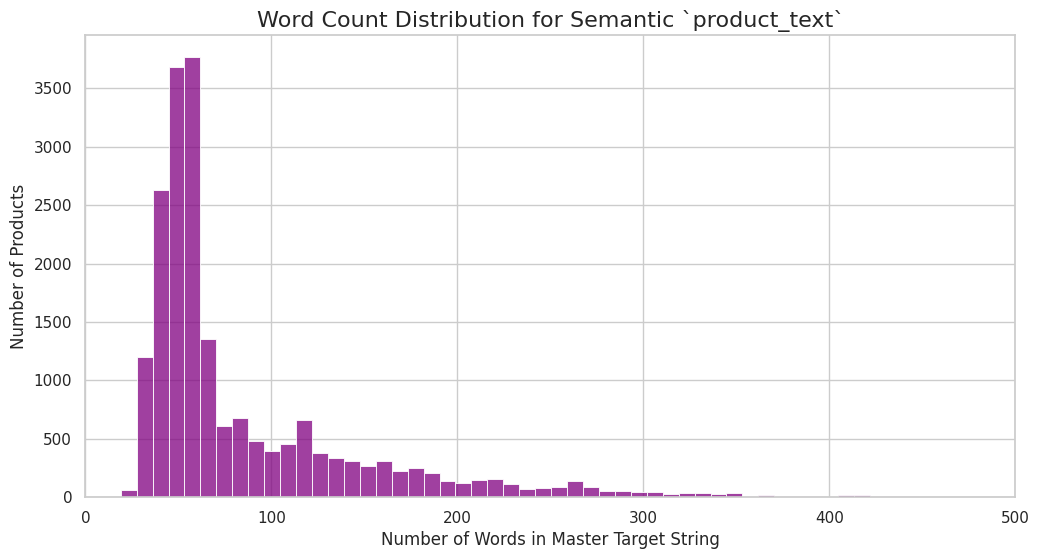

In [ ]:
df['text_word_count'] = df['product_text'].astype(str).apply(lambda x: len(x.split()))

plt.figure(figsize=(12, 6))
sns.histplot(df['text_word_count'], bins=100, color='purple', kde=False)
plt.xlim(0, 500) # Most should fall easily under 500 words
plt.title('Word Count Distribution for Semantic `product_text`', fontsize=16)
plt.xlabel('Number of Words in Master Target String')
plt.ylabel('Number of Products')
plt.show()

Most product texts (name, description, category) are short to medium length, typically under 500 words. This indicates limited textual context, making Sentence Transformers useful for capturing semantic meaning from short descriptions.

### 5. Semantic Word Cloud

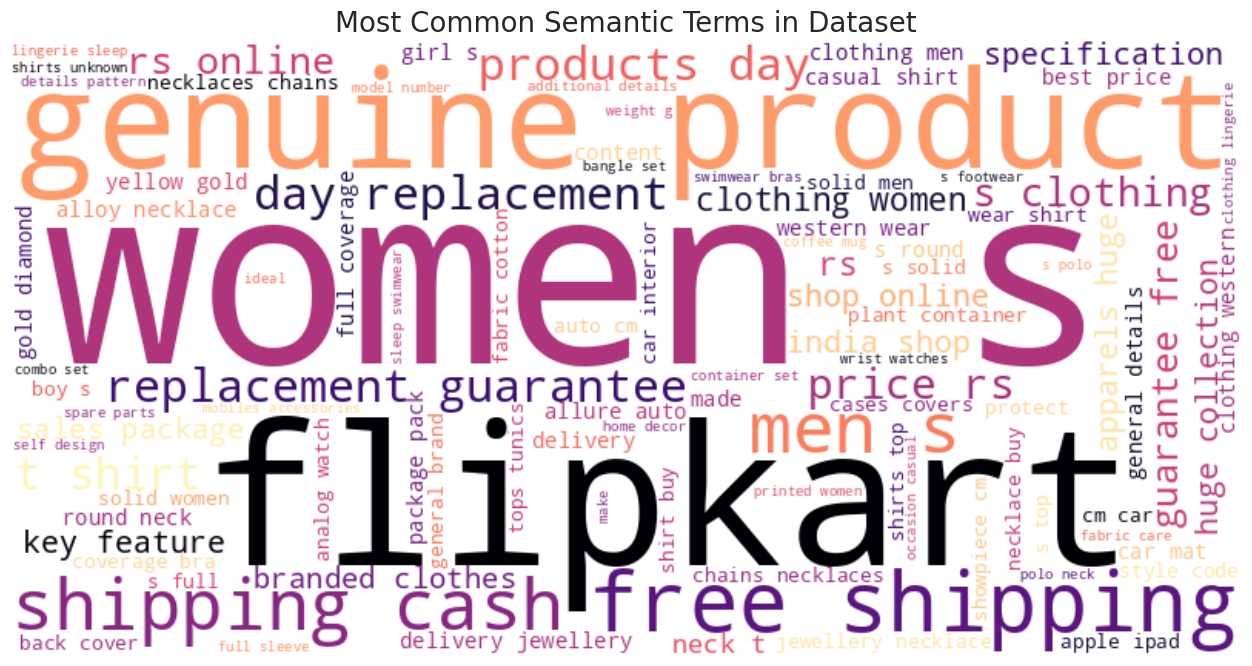

In [ ]:
text = " ".join(df['product_text'].astype(str).tolist())

wordcloud = WordCloud(width=800, height=400, background_color='white', max_words=100, colormap='magma').generate(text)

plt.figure(figsize=(16, 8))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Most Common Semantic Terms in Dataset', fontsize=20)
plt.show()

Frequent words in product text are mostly related to fashion items such as clothing and accessories. This shows that the dataset is domain-focused and contains meaningful patterns useful for semantic embedding.

### 6. Discount Percentage Analytics

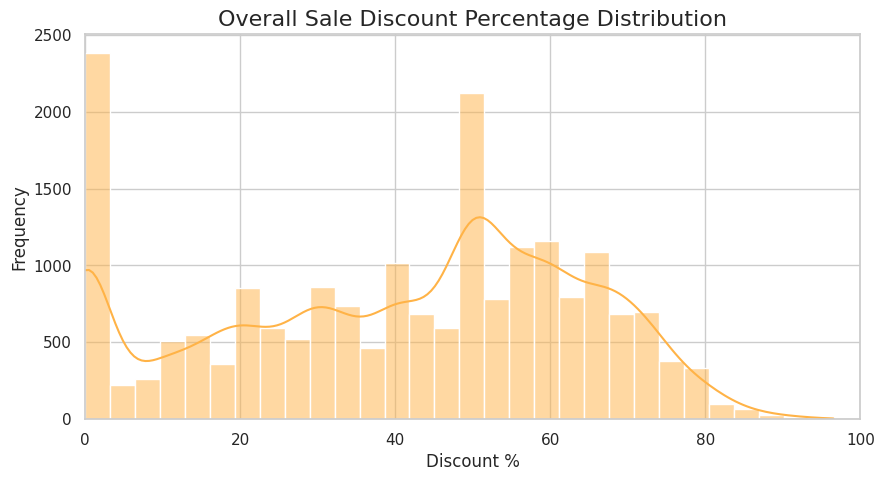

In [ ]:
df['discount_percentage'] = ((df['retail_price'] - df['discounted_price']) / df['retail_price']) * 100
df['discount_percentage'] = df['discount_percentage'].replace([np.inf, -np.inf], 0).fillna(0)

plt.figure(figsize=(10, 5))
sns.histplot(df['discount_percentage'], bins=30, kde=True, color="#ffb347")
plt.title('Overall Sale Discount Percentage Distribution', fontsize=16)
plt.xlabel('Discount %')
plt.ylabel('Frequency')
plt.xlim(0, 100)
plt.show()

Most products have moderate discount values, while high discounts are rare. The distribution is fairly smooth, indicating a consistent pricing strategy across the dataset.

### 7. counting the most frequent words in product names

In [ ]:
from collections import Counter
import re

all_words = []
for name in df['product_name'].dropna():
    words = re.findall(r'\w+', name.lower())
    all_words.extend(words)

Counter(all_words).most_common(20)

[('s', 6391),
 ('women', 4552),
 ('shirt', 2128),
 ('men', 2043),
 ('for', 1990),
 ('set', 1725),
 ('solid', 1637),
 ('casual', 1543),
 ('necklace', 1542),
 ('alloy', 1407),
 ('gold', 1335),
 ('t', 1235),
 ('printed', 1204),
 ('bra', 1114),
 ('neck', 1099),
 ('cm', 1030),
 ('cover', 926),
 ('ipad', 871),
 ('yellow', 856),
 ('full', 812)]

Product names are dominated by fashion-related terms such as men, women, shirt, and casual. This confirms that clothing is the primary category, followed by jewelry and a small portion of electronics.

### 8. Correlation Analysis to Understand relationships between variables and its shows how strongly prices are related.

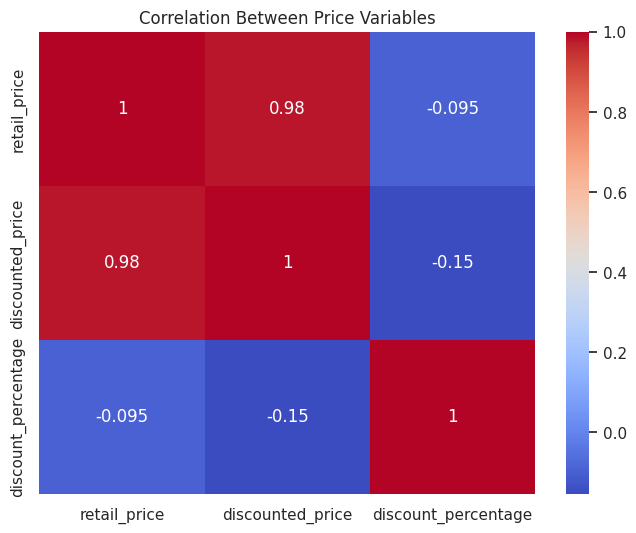

In [ ]:
# Correlation Matrix
corr = df[['retail_price', 'discounted_price', 'discount_percentage']].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Between Price Variables")
plt.show()

Retail price and discounted price are strongly correlated, while discount percentage shows weak correlation with price. This suggests that pricing is consistent, but discount strategies vary across products.

### 9. Top Expensive and Cheapest Products

In [ ]:
# Top expensive
print("Top 10 Expensive Products:")
print(df[['product_name', 'retail_price']].sort_values(by='retail_price', ascending=False).head(10))

# Cheapest
print("\nTop 10 Cheapest Products:")
print(df[['product_name', 'retail_price']].sort_values(by='retail_price').head(10))

Top 10 Expensive Products:
                                            product_name  retail_price
116    breitling ab011010 bb08 131s chronomat 44 anal...      571230.0
11627                       durian leather 2 seater sofa      250500.0
11503                durian laze 3 leather 3 seater sofa      217500.0
11460                       durian leather 2 seater sofa      204600.0
134           cartier w6701005 analog watch for boys men      201000.0
11323                durian club 3 leather 3 seater sofa      162000.0
7914   audeze lcd2 in bamboo high quality planar magn...      116292.0
11698                 durian helena fabric 3 seater sofa      108900.0
11572                 durian helena fabric 3 seater sofa      108900.0
11138               durian dream 2 leather 2 seater sofa      108000.0

Top 10 Cheapest Products:
                                            product_name  retail_price
10550                      geol wooden wet and dry broom          35.0
7411    havells havells

Expensive products include luxury furniture and electronics, while cheap products include stationery and household items. This shows a wide price variation across categories in the dataset.

### 10. Category-wise Price Analysis

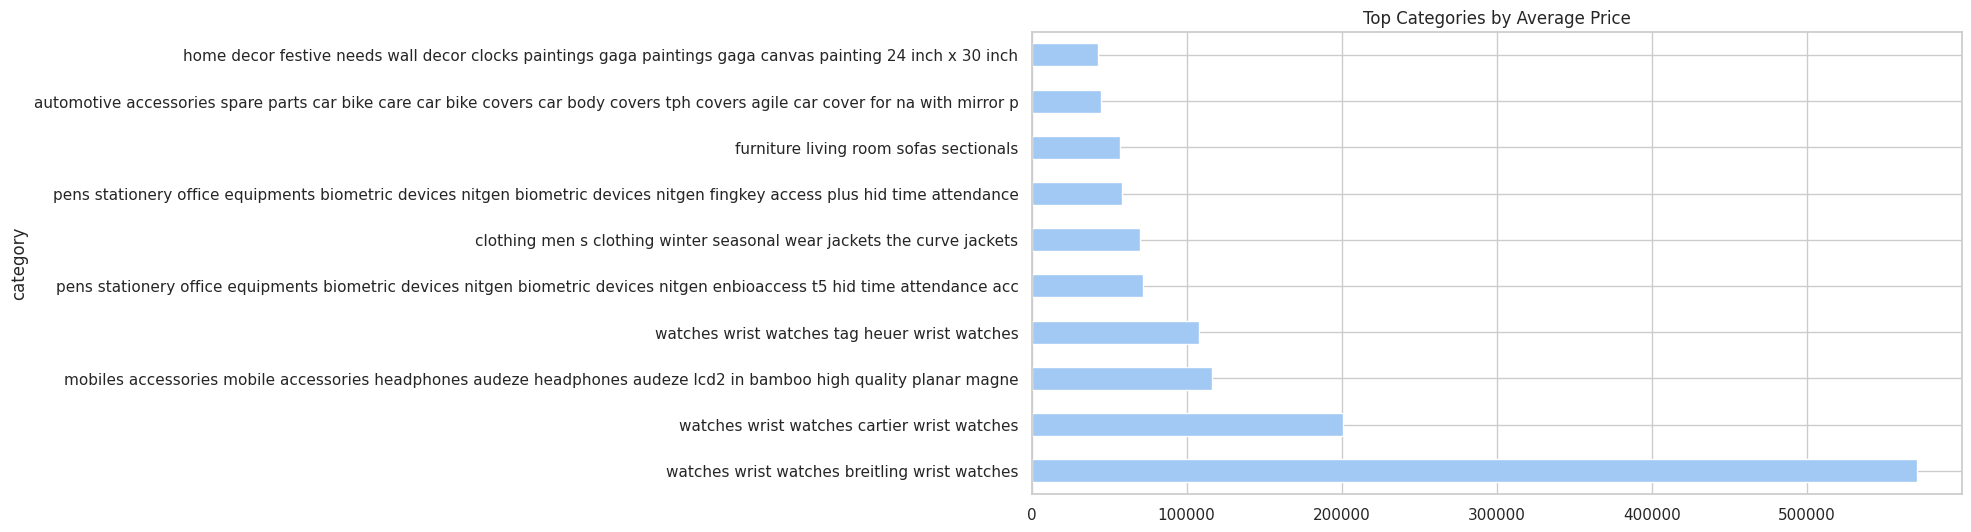

In [ ]:
category_price = df.groupby('category')['retail_price'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,6))
category_price.plot(kind='barh')
plt.title("Top Categories by Average Price")
plt.show()

Some categories have higher average prices, indicating premium segments, while others are budget-oriented. This highlights clear segmentation in product pricing across categories.